# Lending Club Loan Performance & Risk Analysis (2007–2018)
## Stage 3 — Exploratory Data Analysis (EDA)

This is **Chapter 3 of 4**. `02_sql_analysis.ipynb` answered the core business question — *who defaults and at what rate?* — through precise SQL queries: grade (6.7% → 51.4%), term (17.2% → 34.6%), DTI band (16.4% → 31.1%), and a profitability collapse from +$1,926/loan (2013) to −$3,283/loan (2018).

This notebook does two things SQL cannot:
1. **Visualizes** those findings to make the scale and patterns immediately readable
2. **Surfaces interaction effects** — how FICO, DTI, grade, and income compound in the same borrower, creating risk concentrations that no single-dimension query can reveal

## Contents

**Input:** `../data/cleaned_data.csv` — produced by `01_data_cleaning.ipynb`
**SQL findings to confirm and extend:** Default rates by 7 dimensions + vintage profitability arc from `02_sql_analysis.ipynb`

1. **Setup & Data Loading** — Libraries, data load, and quick sanity check.
2. **Univariate Analysis** — Distribution shape, skew, class imbalance, and the floor/ceiling effects SQL aggregates cannot show.
3. **Default Rate by Category** — Visual confirmation of the SQL segment rates; volume vs. rate side by side for each dimension.
4. **Bivariate & Correlation Analysis** — The section SQL cannot do: interaction heatmaps, scatter plots, and the multicollinearity structure of predictors.
5. **Temporal Analysis** — Default rate trends and grade-mix evolution over 2007–2018.
6. **Key Findings** — Full project synthesis across all four stages.

---

## 1. Setup & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Consistent plot style
sns.set_theme(style="whitegrid", palette="Blues_r")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/cleaned_data.csv")

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 1,371,165  |  Columns: 20


,grade,delinq_2yrs,inq_last_6mths,dti,annual_inc,revol_util,loan_amnt,int_rate,term,installment,total_acc,open_acc,mths_since_last_delinq,total_pymnt,default,ever_delinq,purpose_group,credit_history_months,issue_year,fico_score
0,C,0,1,5.91,55000.0,29.7,3600.0,13.99,36,123.03,13,7,30.0,4421.72,0,1,Debt,148,2015,677.0
1,C,1,4,16.06,65000.0,19.2,24700.0,11.99,36,820.28,38,22,6.0,25679.66,0,1,Business,192,2015,717.0
2,B,0,0,10.78,63000.0,56.2,20000.0,10.78,60,432.66,18,6,31.0,22705.92,0,0,Home,184,2015,697.0
3,F,1,3,25.37,104433.0,64.5,10400.0,22.45,60,289.91,35,12,12.0,11740.50,0,1,Consumer,210,2015,697.0
4,C,0,0,10.20,34000.0,68.4,11950.0,13.44,36,405.18,6,5,31.0,13708.95,0,0,Debt,338,2015,692.0


---

## 2. Univariate Analysis

Distributions of individual features before any cross-group comparison. The goal is to understand data shape, spot skew, confirm the class split, and flag any preprocessing needs before modelling.

**Metrics in this section:**

- **Numeric feature distributions** — Loan amount, interest rate, FICO score, and DTI: central tendency, skew, and mean vs. median divergence.
- **Categorical feature distributions** — Volume split by credit grade, purpose group, and loan term.
- **Target variable** — Class split between fully paid (0) and default (1) loans; class imbalance assessment.

### 2.1 Numeric feature distributions

Central tendency and shape of continuous variables. Mean vs. median divergence signals skew; bimodality signals distinct sub-populations worth segmenting.

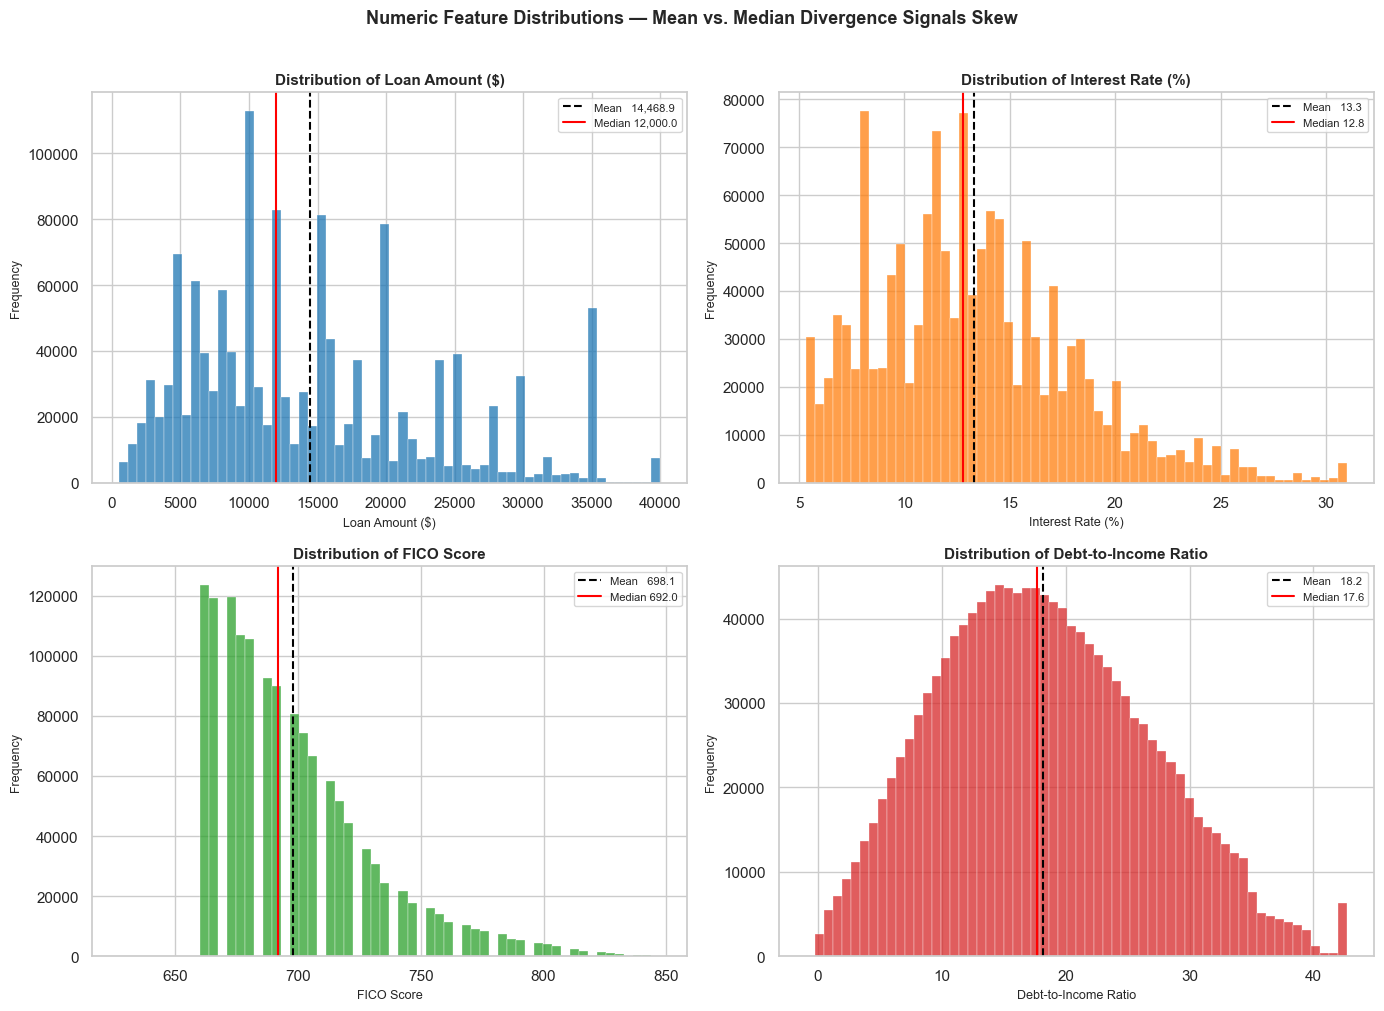

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

numeric_config = {
    "loan_amnt":  ("Loan Amount ($)",       "#1f77b4"),
    "int_rate":   ("Interest Rate (%)",      "#ff7f0e"),
    "fico_score": ("FICO Score",             "#2ca02c"),
    "dti":        ("Debt-to-Income Ratio",   "#d62728"),
}

for ax, (col, (label, color)) in zip(axes.flat, numeric_config.items()):
    col_data   = df[col].dropna()
    mean_val   = col_data.mean()
    median_val = col_data.median()

    ax.hist(col_data, bins=60, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(mean_val,   color="black", linestyle="--", linewidth=1.5, label=f"Mean   {mean_val:,.1f}")
    ax.axvline(median_val, color="red",   linestyle="-",  linewidth=1.5, label=f"Median {median_val:,.1f}")
    ax.set_title(f"Distribution of {label}", fontsize=11, fontweight="bold")
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.8)

plt.suptitle("Numeric Feature Distributions — Mean vs. Median Divergence Signals Skew",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Categorical feature distributions

Volume composition across grade, purpose group, and term — establishes the portfolio's structural mix before comparing default rates in Section 3.

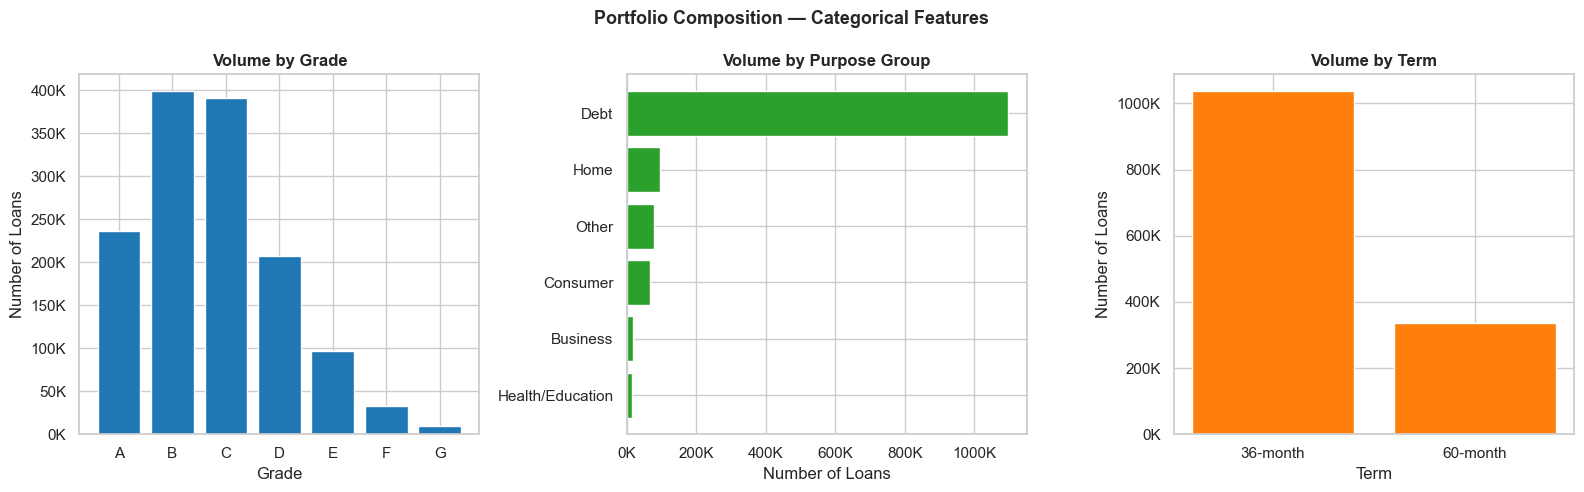

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grade distribution
grade_counts = df["grade"].value_counts().sort_index()
axes[0].bar(grade_counts.index, grade_counts.values, color="#1f77b4", edgecolor="white")
axes[0].set_title("Volume by Grade", fontweight="bold")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Number of Loans")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Purpose group (sorted ascending for horizontal bar readability)
purpose_counts = df["purpose_group"].value_counts().sort_values()
axes[1].barh(purpose_counts.index, purpose_counts.values, color="#2ca02c", edgecolor="white")
axes[1].set_title("Volume by Purpose Group", fontweight="bold")
axes[1].set_xlabel("Number of Loans")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Term
term_counts = df["term"].value_counts().sort_index()
term_labels  = [f"{int(t)}-month" for t in term_counts.index]
axes[2].bar(term_labels, term_counts.values, color="#ff7f0e", edgecolor="white")
axes[2].set_title("Volume by Term", fontweight="bold")
axes[2].set_xlabel("Term")
axes[2].set_ylabel("Number of Loans")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.suptitle("Portfolio Composition — Categorical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Target variable — class imbalance

Default is the binary outcome we are explaining throughout this notebook. Understanding the class split upfront is critical: a 21.5% minority class is moderately imbalanced and must be accounted for in any downstream predictive modelling.

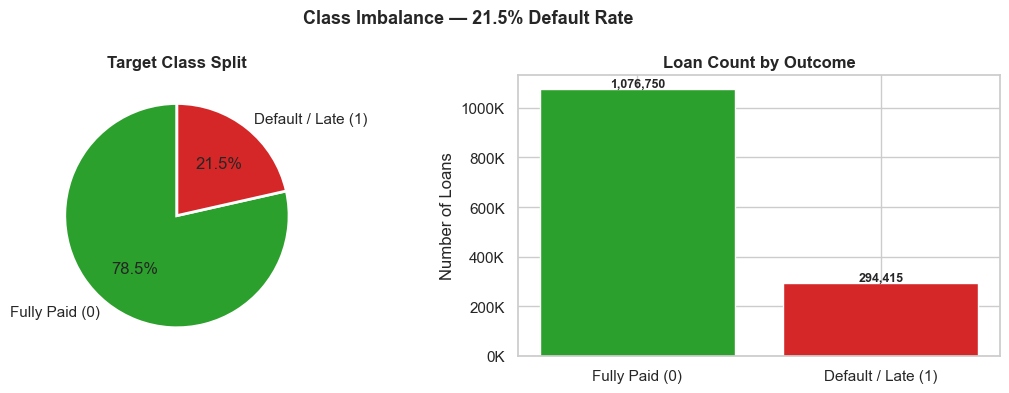

In [25]:
default_counts = df["default"].value_counts().sort_index()
labels = ["Fully Paid (0)", "Default / Late (1)"]
colors  = ["#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(
    default_counts.values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[0].set_title("Target Class Split", fontweight="bold")

bars = axes[1].bar(labels, default_counts.values, color=colors, edgecolor="white")
axes[1].set_title("Loan Count by Outcome", fontweight="bold")
axes[1].set_ylabel("Number of Loans")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar, val in zip(bars, default_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8_000,
        f"{val:,}", ha="center", fontweight="bold", fontsize=9
    )

plt.suptitle("Class Imbalance — 21.5% Default Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Section 2 takeaways

| Feature | Key observation | Business implication |
|---|---|---|
| Loan amount | Right-skewed; modal peaks at $10K, $15K, $20K | Round-number anchoring — borrowers request pre-defined amounts |
| Interest rate | Bimodal: 10–15% cluster (grades B–C) + 20–25% tail (grades E–G) | Rate distribution mirrors risk tiering; upper tail is the high-risk exposure |
| FICO score | Near-symmetric around ~700; hard floor at 600 | Below-600 borrowers excluded entirely — probably rejected dataset has these borrowers |
| DTI | Right-skewed; most borrowers below 25, meaningful tail above 35 | Upper-DTI borrowers have low buffer for income shocks — key default predictor |
| Grade mix | B and C dominate (~50% of volume combined) | Platform optimises for mid-risk volume, not safety-first origination |
| Purpose | Debt consolidation is ~50% of all loans | Single-purpose concentration — overall portfolio health is tied to this segment |
| Term | 36-month loans outnumber 60-month roughly 2:1 | 60-month selection skews toward higher-risk borrowers |
| Default split | 78.5% non-default / 21.5% default | Class imbalance for modeling |

---

## 3. Default Rate by Category

`02_sql_analysis.ipynb` already computed these segment rates as table rows. Here we pair **loan volume (left) and default rate (right)** side by side for each dimension — because a segment can look dangerous in isolation but represent too little volume to matter, or carry massive volume at a below-average rate. The visual layer makes that trade-off immediately readable at a glance.

Each sub-section plots both bars together, with a dashed line marking the **21.47% portfolio average** established in Section 2.1 of the SQL notebook.

**Metrics in this section:**

- **By purpose group** — Default rate and volume for Debt, Home, Consumer, Business, Health/Education, and Other.
- **By credit grade** — Risk profile from Grade A (6.7%) to Grade G (51.4%).
- **By FICO band** — Default rate across Poor / Fair / Good / Excellent credit tiers.
- **By loan term** — Default rate for 36-month vs. 60-month loans.
- **By DTI** — Default rate across different DTI bands.

### 3.1 Default rate by purpose group

Purpose tests whether the *reason* for borrowing predicts repayment behavior — and whether high-volume segments carry more or less risk than the portfolio average.

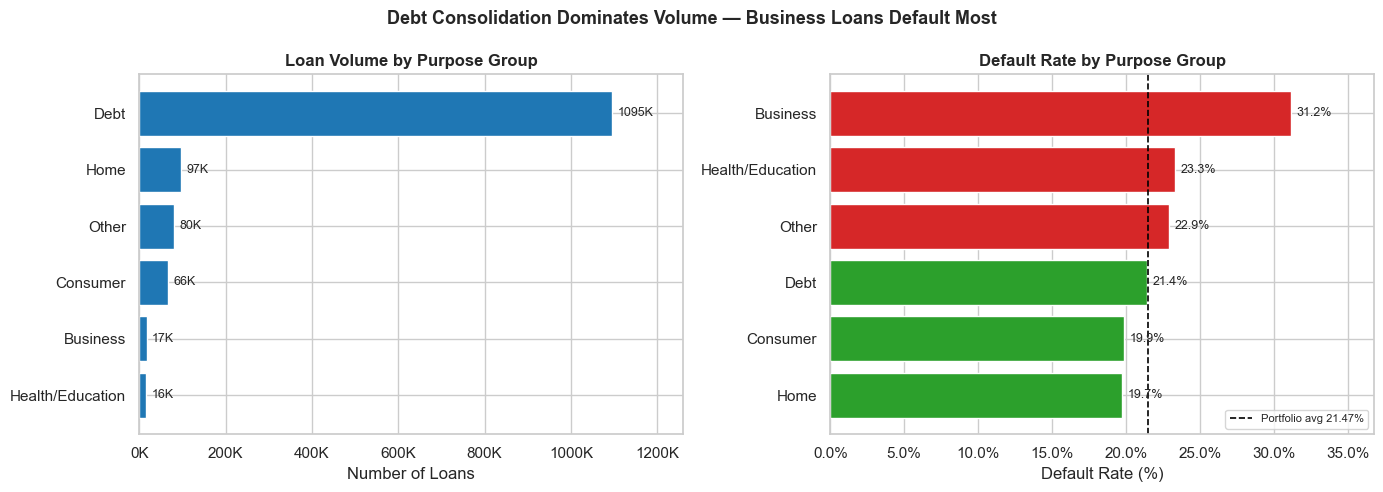

In [26]:
PORTFOLIO_AVG = 21.47

purpose_stats = (
    df.groupby("purpose_group")["default"]
    .agg(total="count", defaults="sum")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
)

purpose_by_vol  = purpose_stats.sort_values("total")
purpose_by_rate = purpose_stats.sort_values("default_rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Volume ---
bars0 = axes[0].barh(purpose_by_vol.index, purpose_by_vol["total"], color="#1f77b4", edgecolor="white")
axes[0].bar_label(bars0, labels=[f"{v/1e3:.0f}K" for v in purpose_by_vol["total"]], padding=4, fontsize=9)
axes[0].set_title("Loan Volume by Purpose Group", fontweight="bold")
axes[0].set_xlabel("Number of Loans")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].set_xlim(right=purpose_by_vol["total"].max() * 1.15)

# --- Right: Default Rate ---
rate_colors = ["#2ca02c" if r < PORTFOLIO_AVG else "#d62728" for r in purpose_by_rate["default_rate"]]
bars1 = axes[1].barh(purpose_by_rate.index, purpose_by_rate["default_rate"], color=rate_colors, edgecolor="white")
axes[1].bar_label(bars1, fmt="%.1f%%", padding=4, fontsize=9)
axes[1].axvline(PORTFOLIO_AVG, color="black", linestyle="--", linewidth=1.2, label=f"Portfolio avg {PORTFOLIO_AVG}%")
axes[1].set_title("Default Rate by Purpose Group", fontweight="bold")
axes[1].set_xlabel("Default Rate (%)")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlim(right=purpose_by_rate["default_rate"].max() * 1.18)
axes[1].legend(fontsize=8)

plt.suptitle("Debt Consolidation Dominates Volume — Business Loans Default Most", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Default rate by credit grade

Credit grade is Lending Club's internal risk score — the primary segmentation variable for pricing, and the strongest single predictor of default in this dataset.

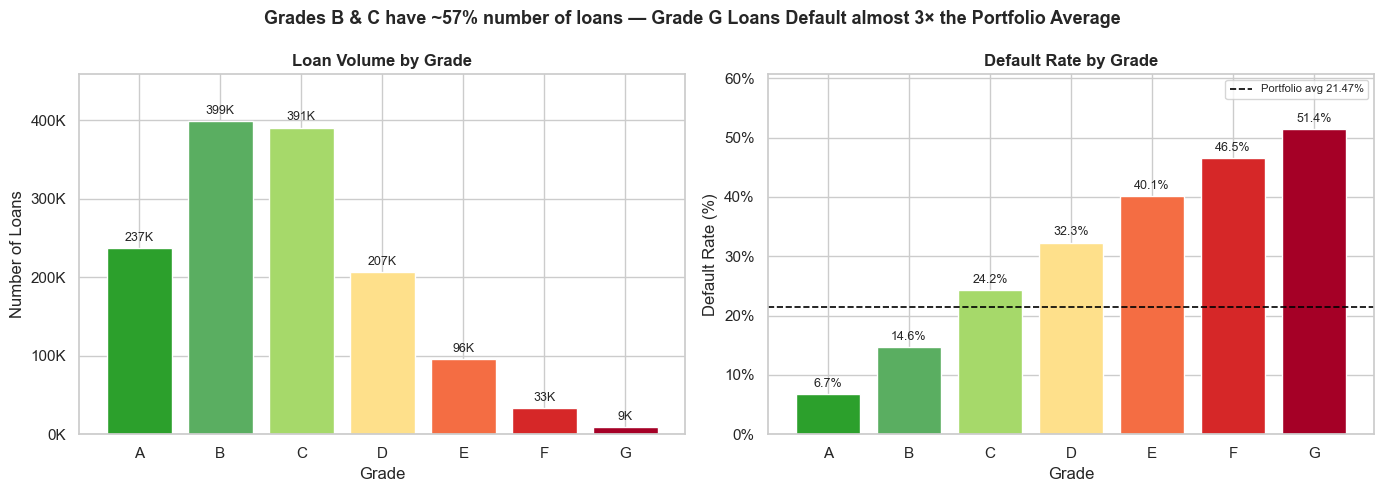

In [27]:
PORTFOLIO_AVG = 21.47

grade_stats = (
    df.groupby("grade")["default"]
    .agg(total="count", defaults="sum")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
    .sort_index()
)

# Green → Red gradient across grades A to G
grade_colors = ["#2ca02c", "#5aae61", "#a6d96a", "#fee08b", "#f46d43", "#d62728", "#a50026"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Volume ---
bars0 = axes[0].bar(grade_stats.index, grade_stats["total"], color=grade_colors, edgecolor="white")
axes[0].bar_label(bars0, labels=[f"{v/1e3:.0f}K" for v in grade_stats["total"]], padding=3, fontsize=9)
axes[0].set_title("Loan Volume by Grade", fontweight="bold")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Number of Loans")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].set_ylim(top=grade_stats["total"].max() * 1.15)

# --- Right: Default Rate ---
bars1 = axes[1].bar(grade_stats.index, grade_stats["default_rate"], color=grade_colors, edgecolor="white")
axes[1].bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].axhline(PORTFOLIO_AVG, color="black", linestyle="--", linewidth=1.2, label=f"Portfolio avg {PORTFOLIO_AVG}%")
axes[1].set_title("Default Rate by Grade", fontweight="bold")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Default Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(top=grade_stats["default_rate"].max() * 1.18)
axes[1].legend(fontsize=8)

plt.suptitle("Grades B & C have ~57% number of loans — Grade G Loans Default almost 3× the Portfolio Average",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Default rate by FICO band

FICO score measures a borrower's credit history and repayment track record. Banding into four tiers reveals how volume distributes across credit quality levels and how each tier compares to the portfolio average.

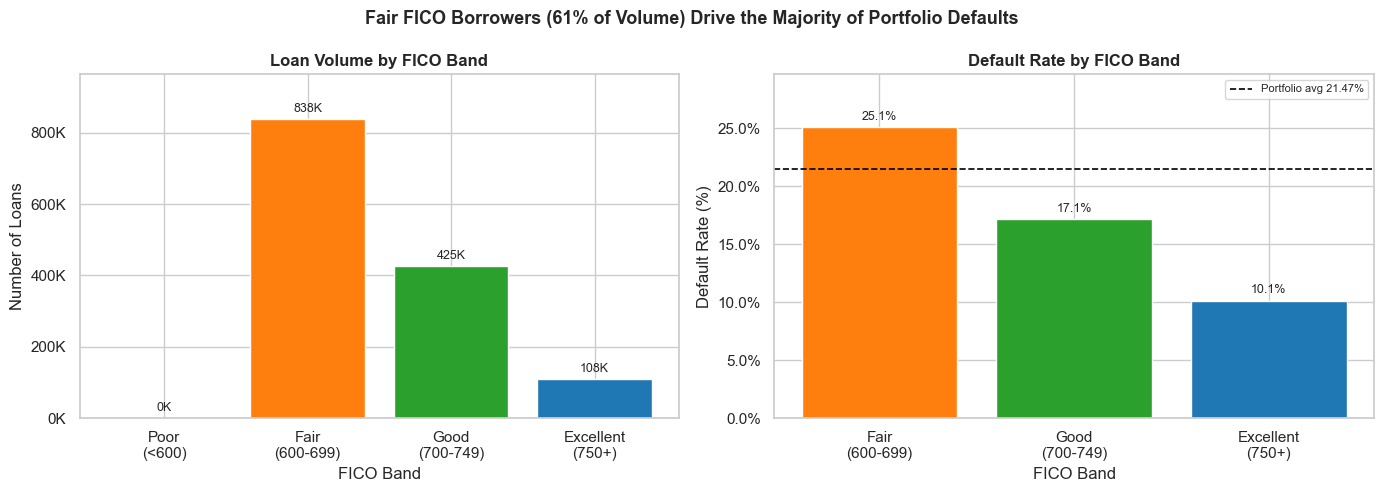

In [28]:
PORTFOLIO_AVG = 21.47

fico_bands = pd.cut(
    df["fico_score"],
    bins=[0, 600, 700, 750, 900],
    labels=["Poor\n(<600)", "Fair\n(600-699)", "Good\n(700-749)", "Excellent\n(750+)"]
)

fico_stats = (
    df.assign(fico_band=fico_bands)
    .groupby("fico_band", observed=False)["default"]
    .agg(total="count", defaults="sum")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
)

band_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Volume ---
bars0 = axes[0].bar(fico_stats.index, fico_stats["total"], color=band_colors, edgecolor="white")
axes[0].bar_label(bars0, labels=[f"{v/1e3:.0f}K" for v in fico_stats["total"]], padding=3, fontsize=9)
axes[0].set_title("Loan Volume by FICO Band", fontweight="bold")
axes[0].set_xlabel("FICO Band")
axes[0].set_ylabel("Number of Loans")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].set_ylim(top=fico_stats["total"].max() * 1.15)

# --- Right: Default Rate ---
bars1 = axes[1].bar(fico_stats.index, fico_stats["default_rate"], color=band_colors, edgecolor="white")
axes[1].bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].axhline(PORTFOLIO_AVG, color="black", linestyle="--", linewidth=1.2, label=f"Portfolio avg {PORTFOLIO_AVG}%")
axes[1].set_title("Default Rate by FICO Band", fontweight="bold")
axes[1].set_xlabel("FICO Band")
axes[1].set_ylabel("Default Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(top=fico_stats["default_rate"].max() * 1.18)
axes[1].legend(fontsize=8)

plt.suptitle("Fair FICO Borrowers (61% of Volume) Drive the Majority of Portfolio Defaults",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Default rate by loan term

Loan term is a structural risk amplifier: a longer repayment window gives borrowers more exposure to income shocks, job loss, and financial distress events over the life of the loan.

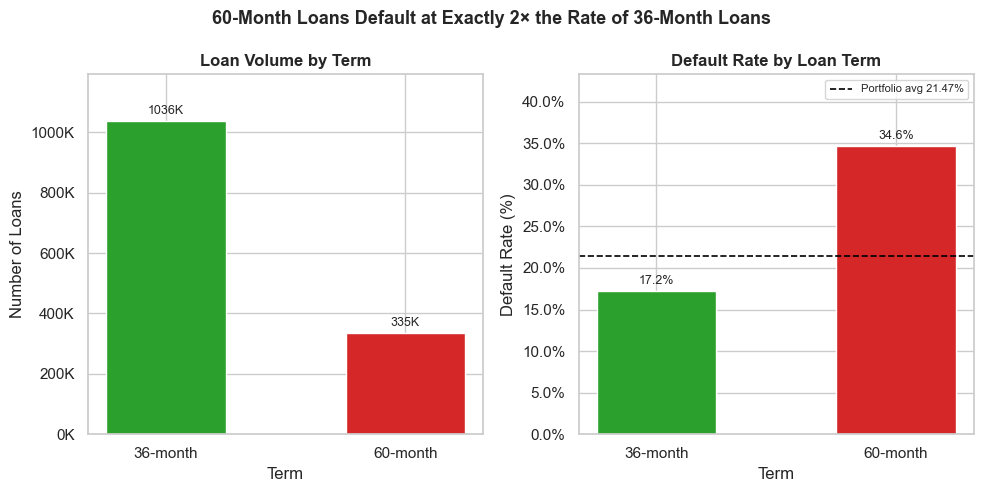

In [29]:
PORTFOLIO_AVG = 21.47

term_stats = (
    df.groupby("term")["default"]
    .agg(total="count", defaults="sum")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
    .sort_index()
)

term_labels = [f"{int(t)}-month" for t in term_stats.index]
term_colors  = ["#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Left: Volume ---
bars0 = axes[0].bar(term_labels, term_stats["total"], color=term_colors, edgecolor="white", width=0.5)
axes[0].bar_label(bars0, labels=[f"{v/1e3:.0f}K" for v in term_stats["total"]], padding=3, fontsize=9)
axes[0].set_title("Loan Volume by Term", fontweight="bold")
axes[0].set_xlabel("Term")
axes[0].set_ylabel("Number of Loans")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].set_ylim(top=term_stats["total"].max() * 1.15)

# --- Right: Default Rate ---
bars1 = axes[1].bar(term_labels, term_stats["default_rate"], color=term_colors, edgecolor="white", width=0.5)
axes[1].bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].axhline(PORTFOLIO_AVG, color="black", linestyle="--", linewidth=1.2, label=f"Portfolio avg {PORTFOLIO_AVG}%")
axes[1].set_title("Default Rate by Loan Term", fontweight="bold")
axes[1].set_xlabel("Term")
axes[1].set_ylabel("Default Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(top=term_stats["default_rate"].max() * 1.25)
axes[1].legend(fontsize=8)

plt.suptitle("60-Month Loans Default at Exactly 2× the Rate of 36-Month Loans",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.5 Default rate by DTI

Debt-to-income ratio measures how much of a borrower's gross income is already committed to debt repayment. Higher DTI leaves less financial cushion to absorb unexpected shocks — making it a forward-looking stress indicator independent of credit history.

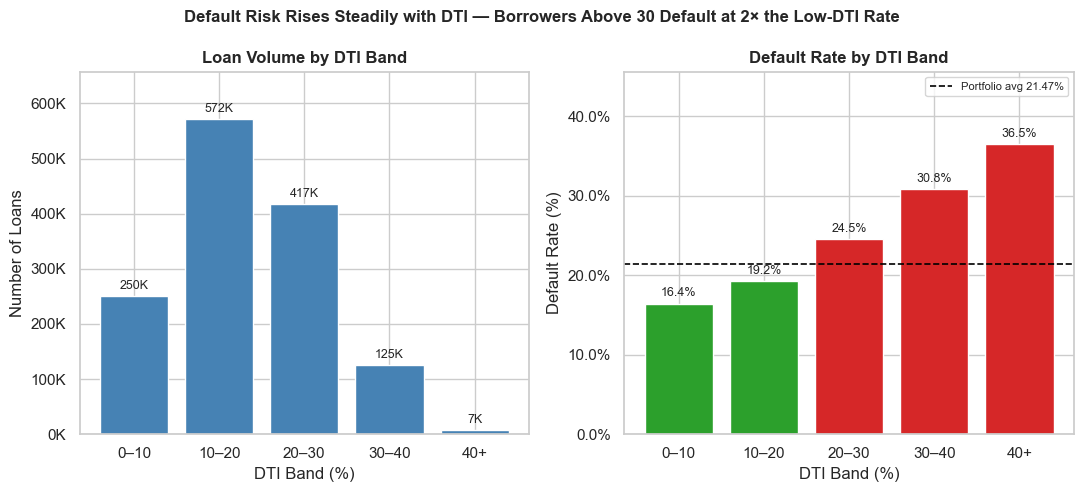

           total  defaults  default_rate
dti_band                                
0–10      250258     41120     16.431043
10–20     571897    109914     19.219195
20–30     416700    102223     24.531557
30–40     124904     38456     30.788446
40+         7404      2702     36.493787


In [30]:
PORTFOLIO_AVG = 21.47

dti_bins   = [0, 10, 20, 30, 40, df["dti"].max() + 1]
dti_labels = ["0–10", "10–20", "20–30", "30–40", "40+"]

dti_stats = (
    df.assign(dti_band=pd.cut(df["dti"], bins=dti_bins, labels=dti_labels, right=False))
    .groupby("dti_band", observed=True)["default"]
    .agg(total="count", defaults="sum")
    .assign(default_rate=lambda x: x["defaults"] / x["total"] * 100)
)

palette = ["#2ca02c" if r < PORTFOLIO_AVG else "#d62728" for r in dti_stats["default_rate"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Left: Volume ---
bars0 = axes[0].bar(dti_stats.index, dti_stats["total"], color="steelblue", edgecolor="white")
axes[0].bar_label(bars0, labels=[f"{v/1e3:.0f}K" for v in dti_stats["total"]], padding=3, fontsize=9)
axes[0].set_title("Loan Volume by DTI Band", fontweight="bold")
axes[0].set_xlabel("DTI Band (%)")
axes[0].set_ylabel("Number of Loans")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
axes[0].set_ylim(top=dti_stats["total"].max() * 1.15)

# --- Right: Default Rate ---
bars1 = axes[1].bar(dti_stats.index, dti_stats["default_rate"], color=palette, edgecolor="white")
axes[1].bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].axhline(PORTFOLIO_AVG, color="black", linestyle="--", linewidth=1.2,
                label=f"Portfolio avg {PORTFOLIO_AVG}%")
axes[1].set_title("Default Rate by DTI Band", fontweight="bold")
axes[1].set_xlabel("DTI Band (%)")
axes[1].set_ylabel("Default Rate (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(top=dti_stats["default_rate"].max() * 1.25)
axes[1].legend(fontsize=8)

plt.suptitle("Default Risk Rises Steadily with DTI — Borrowers Above 30 Default at 2× the Low-DTI Rate",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(dti_stats.to_string())

### Section 3 takeaways

| Segment | Key observation | Business implication |
|---|---|---|
| Purpose: Debt consolidation | ~50% of volume; default rate ~21.4% (near portfolio avg) | Portfolio default rate is almost entirely shaped by this one segment — small shifts here move the overall average |
| Purpose: Business | **31.2% default** — highest of all purpose groups | Loss-making at current pricing; confirmed as -$11.5M profit in `02_sql_analysis.ipynb` |
| Credit grade | Default rises monotonically from **6.7% (A) → 51.4% (G)** — 44.7pp spread | Grade is the strongest single risk differentiator in the dataset, with a range that dwarfs all other variables |
| Grade mix | B + C hold ~57% of volume at 14.6% and 24.2% in default | Platform deliberately concentrates in mid-risk origination; D–G contribute disproportionate losses at only ~23% of loans |
| FICO band | Fair (600–699): **25.1%**; Excellent (750+): **10.1%** — 15pp spread | Fair band holds 61% of volume (~837K loans) — highest-leverage segment for underwriting adjustment |
| Loan term | 60-month: **34.6%** default — exactly **2× the 36-month rate (17.2%)** | Term is a structural risk amplifier; 60-month loans warrant distinct underwriting criteria and pricing |
| DTI band | Borrowers with DTI 30+ default at roughly **2× the rate of DTI 0–10** | DTI is a forward-looking stress indicator — combining DTI with grade and FICO materially sharpens borrower risk segmentation |

---

## 4. Bivariate & Correlation Analysis

Sections 2 and 3 confirmed what the SQL queries already showed — segment-level default rates that hold up visually. This section goes beyond what SQL can easily produce: it examines **how variables interact with each other**.

Four analyses that single-dimension SQL queries cannot cleanly surface:

- **Correlation heatmap** — Pearson correlations across all numeric features, flagging multicollinear pairs. The critical finding: grade and interest rate are near-perfectly correlated (r ≈ 0.95) — using both in any model or scorecard adds collinearity without adding predictive power.
- **Interest rate by grade (default vs. non-default)** — Within each grade, whether defaulted loans were priced differently. This tests whether the platform's rate-setting already anticipated intra-grade risk differences — and by how much.
- **FICO vs. DTI scatter** — The joint default pattern across two dimensions simultaneously. This reveals the high-density overlap zone at FICO 650–700 / DTI 15–30 where no single threshold cleanly separates defaulters from payers.
- **Income × Grade & Income × DTI heatmaps** — How income interacts with grade and debt load. Income alone shows a narrow 6.8pp spread across bands; crossed with grade and DTI, it surfaces compounding pockets where multiple risk factors stack.

**Metrics in this section:**

- **Correlation heatmap** — Pearson correlations across all numeric features; flags multicollinear pairs (e.g. grade vs. int_rate).
- **Interest rate by grade (default vs. non-default)** — Whether defaulted loans were priced differently within each grade band.
- **FICO vs. DTI scatter** — Joint default patterns across the two-dimensional credit quality / affordability space.
- **Income × Grade & Income × DTI heatmaps** — Combined risk surface showing how income interacts with grade and debt load to produce compounding default risk.

### 4.1 Correlation heatmap of numeric features

A Pearson correlation matrix across all numeric columns — flags linear relationships between predictors and with the `default` target, and identifies multicollinear variable pairs that would be problematic in a regression or scoring model.

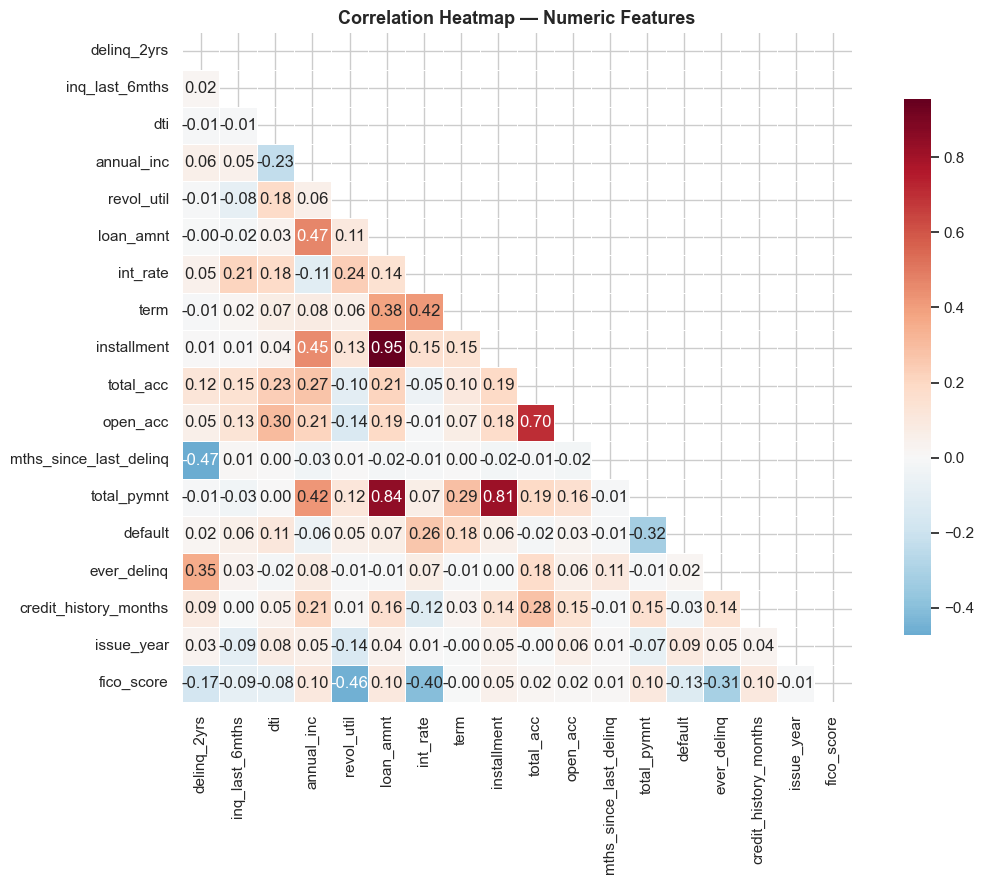

In [31]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Interest rate by grade (default vs. non-default)

Within each grade, this boxplot shows whether defaulted and non-defaulted loans were priced differently — testing whether the platform's rate-setting anticipated intra-grade risk differences.

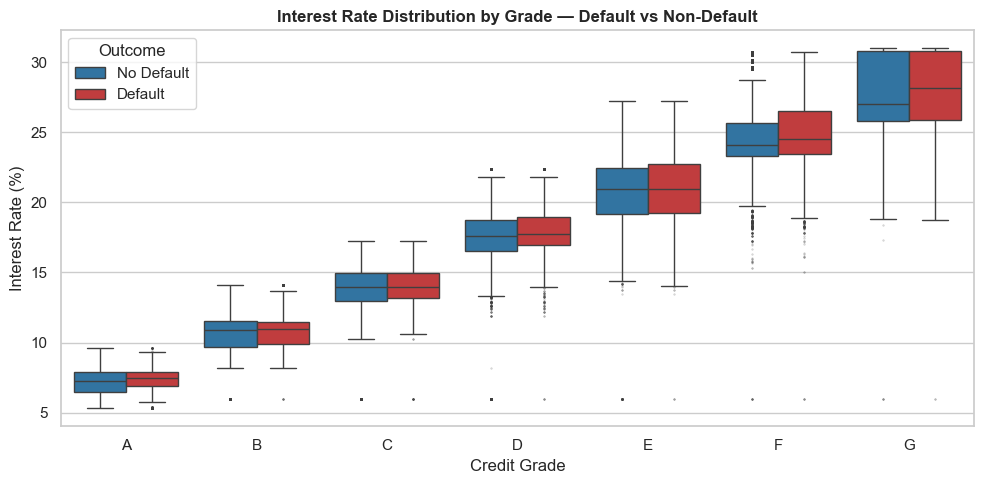

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, x="grade", y="int_rate", hue="default",
    order=sorted(df["grade"].dropna().unique()),
    palette={0: "#1f77b4", 1: "#d62728"},
    flierprops=dict(marker=".", markersize=1, alpha=0.3)
)
plt.title("Interest Rate Distribution by Grade — Default vs Non-Default", fontsize=12, fontweight="bold")
plt.xlabel("Credit Grade")
plt.ylabel("Interest Rate (%)")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["No Default", "Default"], title="Outcome")
plt.tight_layout()
plt.show()

### 4.3 FICO Score vs DTI — Default Patterns

A random sample of 10,000 loans is used to keep the scatter plot readable.

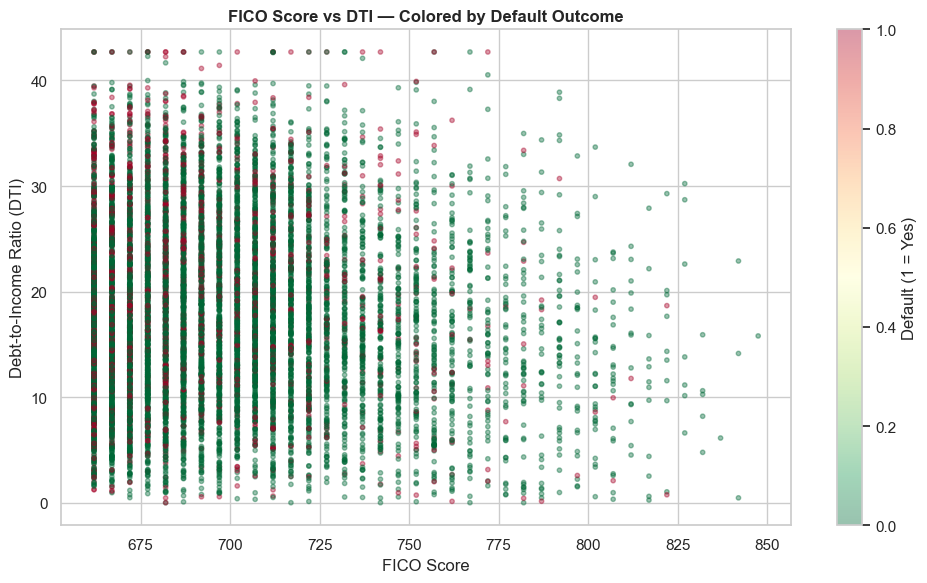

In [33]:
sample = df.sample(10_000, random_state=42)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    sample["fico_score"], sample["dti"],
    c=sample["default"], cmap="RdYlGn_r",
    alpha=0.4, s=10
)
cbar = plt.colorbar(scatter)
cbar.set_label("Default (1 = Yes)")
plt.title("FICO Score vs DTI — Colored by Default Outcome", fontsize=12, fontweight="bold")
plt.xlabel("FICO Score")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.tight_layout()
plt.show()

### 4.4 Income × Grade × DTI — Combined Risk Surface

Income alone showed a narrow 6.8pp spread across bands — too small to be actionable on its own. Crossing income with credit grade and DTI surfaces the compounding effect: low-income borrowers in high-risk grades or with stretched debt loads face materially higher default rates, while high income provides limited protection once grade and DTI are unfavorable. Two heatmaps expose this interaction — warm cells mark pockets where multiple risk factors stack.

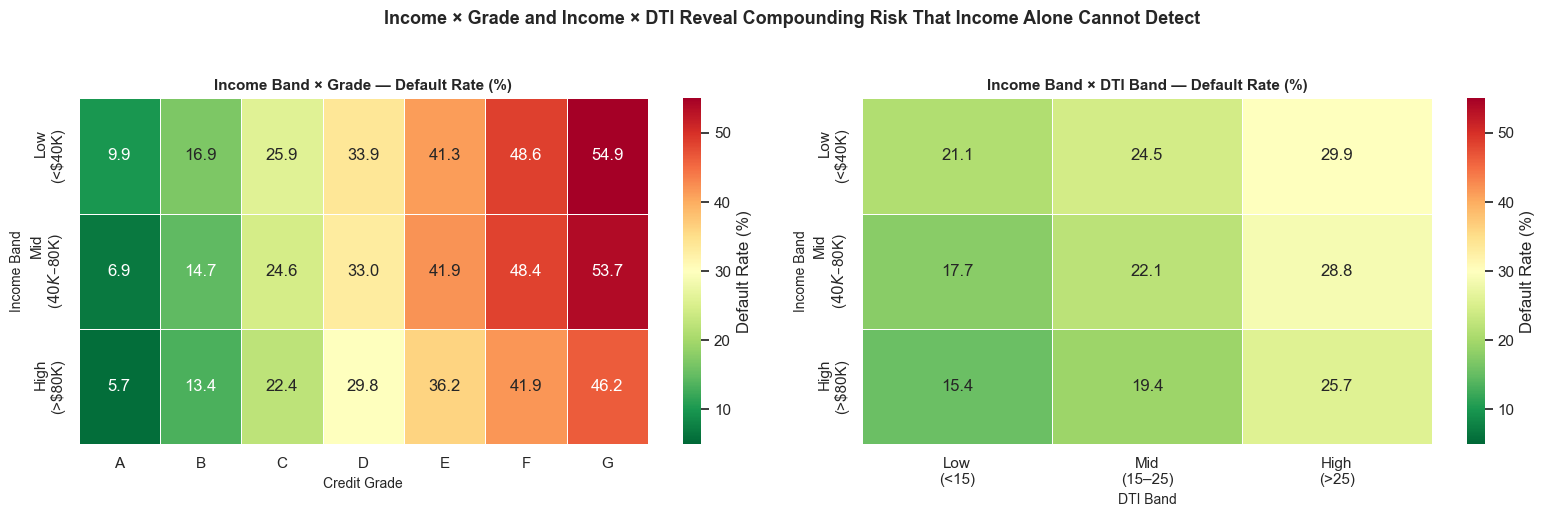

In [34]:
PORTFOLIO_AVG = 21.47

income_bins   = [0, 40_000, 80_000, df["annual_inc"].max() + 1]
income_labels = ["Low\n(<$40K)", "Mid\n($40K–$80K)", "High\n(>$80K)"]

dti_bins   = [-1, 15, 25, df["dti"].max() + 1]
dti_labels = ["Low\n(<15)", "Mid\n(15–25)", "High\n(>25)"]

df_tmp = df.assign(
    income_band=pd.cut(df["annual_inc"], bins=income_bins, labels=income_labels),
    dti_band=pd.cut(df["dti"],           bins=dti_bins,   labels=dti_labels),
)

pivot_grade = (
    df_tmp.groupby(["income_band", "grade"], observed=True)["default"]
    .mean().mul(100)
    .unstack("grade")
    .reindex(income_labels)
)

pivot_dti = (
    df_tmp.groupby(["income_band", "dti_band"], observed=True)["default"]
    .mean().mul(100)
    .unstack("dti_band")
    .reindex(income_labels)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Income × Grade and Income × DTI Reveal Compounding Risk That Income Alone Cannot Detect",
    fontsize=13, fontweight="bold", y=1.03,
)

# Panel 1 — Income × Grade
sns.heatmap(
    pivot_grade, ax=axes[0],
    cmap="RdYlGn_r", annot=True, fmt=".1f",
    linewidths=0.5, vmin=5, vmax=55,
    cbar_kws={"label": "Default Rate (%)"},
)
axes[0].set_title("Income Band × Grade — Default Rate (%)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Credit Grade", fontsize=10)
axes[0].set_ylabel("Income Band", fontsize=10)

# Panel 2 — Income × DTI
sns.heatmap(
    pivot_dti, ax=axes[1],
    cmap="RdYlGn_r", annot=True, fmt=".1f",
    linewidths=0.5, vmin=5, vmax=55,
    cbar_kws={"label": "Default Rate (%)"},
)
axes[1].set_title("Income Band × DTI Band — Default Rate (%)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("DTI Band", fontsize=10)
axes[1].set_ylabel("Income Band", fontsize=10)

plt.tight_layout()
plt.show()

### Section 4 takeaways

| Analysis | Key observation | Business implication |
|---|---|---|
| Int. rate by grade (default vs. paid) | Defaulted loans carry higher median rate within every grade; gap widest in C–E | Rate encodes intra-grade risk the platform already detected — deviation from grade-mean rate is a viable engineered feature |
| Correlation: fico_score vs. default | Strongest negative correlation with default among numeric features | FICO is the top numeric predictor; combine with grade for full risk signal |
| Correlation: dti / annual_inc | Weak individual correlations with default | These variables gain predictive power in cross-variable combinations, not as standalone inputs |
| FICO vs. DTI scatter | Defaults cluster in low-FICO / high-DTI quadrant; heavy overlap at FICO 650–700 / DTI 15–30 | No single threshold cleanly separates defaults — multi-variable scoring outperforms any single cutoff |
| Income × Grade & Income × DTI heatmaps | High income does not protect in grade D–G; low income + high DTI compounds default risk significantly | Income must be read alongside grade and DTI — a high earner in grade F remains high-risk; a low earner with grade A and low DTI is not automatically safe, but their risk profile is far closer to the 6.7% portfolio floor than the 51.4% ceiling |

---

## 5. Temporal Analysis

The portfolio spans 12 vintage years (2007–2018), during which loan volume and grade mix both shifted materially. Analyzing these dimensions over time reveals how growth strategy and borrower composition changed — and provides critical context for interpreting snapshot-level default rates seen in sections 2 and 3.

**Metrics in this section:**

- **Loan volume trend** — Annual origination count; identifies the growth arc and the 2015–2016 peak.
- **Vintage default rate** — Default rate by issue year; note that 2017–2018 rates are downward-biased (many loans still active, not yet charged off).
- **Default rate by grade × vintage** — Whether individual grade cohorts became riskier across issue years, pointing to a mix effect or underwriting loosening.

### 5.1 Loan volume growth and vintage default rate

Macro portfolio trajectory from 2007 to 2018. Volume bars show annual origination scale; the trend line tracks each vintage cohort's realized default rate against the portfolio average. **Maturity bias note:** 2017–2018 default rates appear lower because many loans in these cohorts are still active and have not yet had time to charge off — they will rise as loans complete their term.

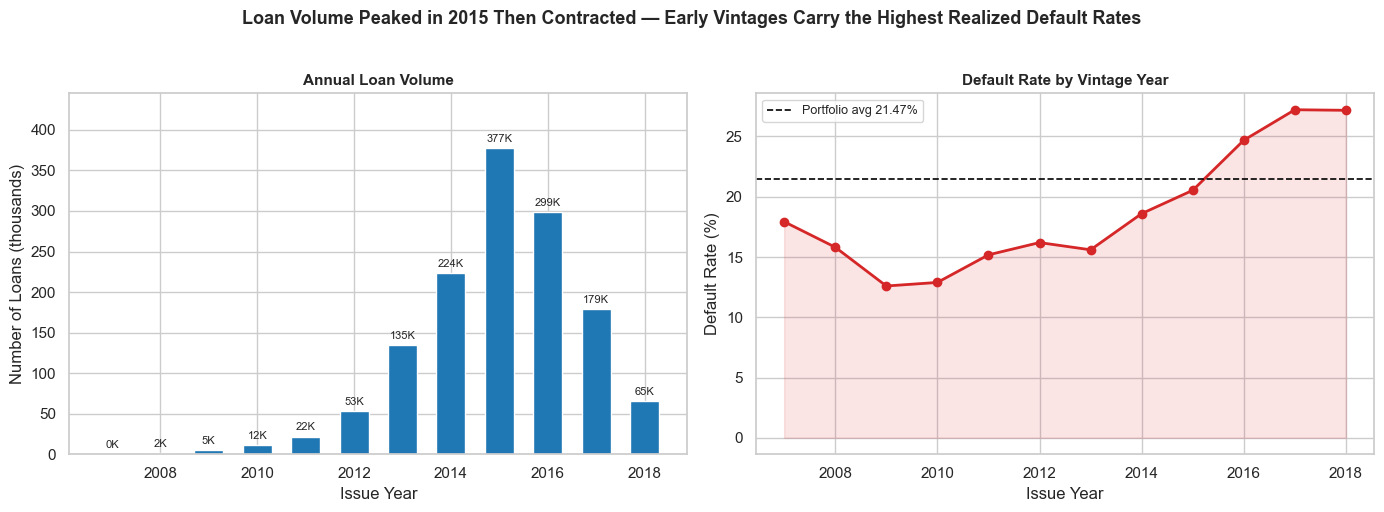

In [35]:
PORTFOLIO_AVG = 21.47

yearly = df.groupby("issue_year").agg(
    loan_count=("default", "count"),
    default_rate=("default", "mean"),
    avg_loan_amnt=("loan_amnt", "mean"),
).reset_index()
yearly["default_rate"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Loan Volume Peaked in 2015 Then Contracted — Early Vintages Carry the Highest Realized Default Rates",
    fontsize=13, fontweight="bold", y=1.02,
)

# Left — Loan Volume
bars = axes[0].bar(yearly["issue_year"], yearly["loan_count"] / 1_000, color="#1f77b4", width=0.6)
axes[0].bar_label(bars, labels=[f"{v:.0f}K" for v in yearly["loan_count"] / 1_000], padding=3, fontsize=8)
axes[0].set_title("Annual Loan Volume", fontweight="bold", fontsize=11)
axes[0].set_xlabel("Issue Year")
axes[0].set_ylabel("Number of Loans (thousands)")
axes[0].set_ylim(top=yearly["loan_count"].max() / 1_000 * 1.18)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Right — Vintage Default Rate
axes[1].plot(yearly["issue_year"], yearly["default_rate"], marker="o", color="#d62728", linewidth=2)
axes[1].fill_between(yearly["issue_year"], yearly["default_rate"], alpha=0.12, color="#d62728")
axes[1].axhline(PORTFOLIO_AVG, color="black", linestyle="--", linewidth=1.2,
                label=f"Portfolio avg {PORTFOLIO_AVG}%")
axes[1].set_title("Default Rate by Vintage Year", fontweight="bold", fontsize=11)
axes[1].set_xlabel("Issue Year")
axes[1].set_ylabel("Default Rate (%)")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### 5.2 Grade mix evolution and default rate by vintage

How the portfolio's A–G grade composition shifted as origination volume scaled. The heatmap tests whether each grade's realized default rate was stable across vintage years or worsened — the latter would indicate underwriting loosening beyond a simple mix effect.

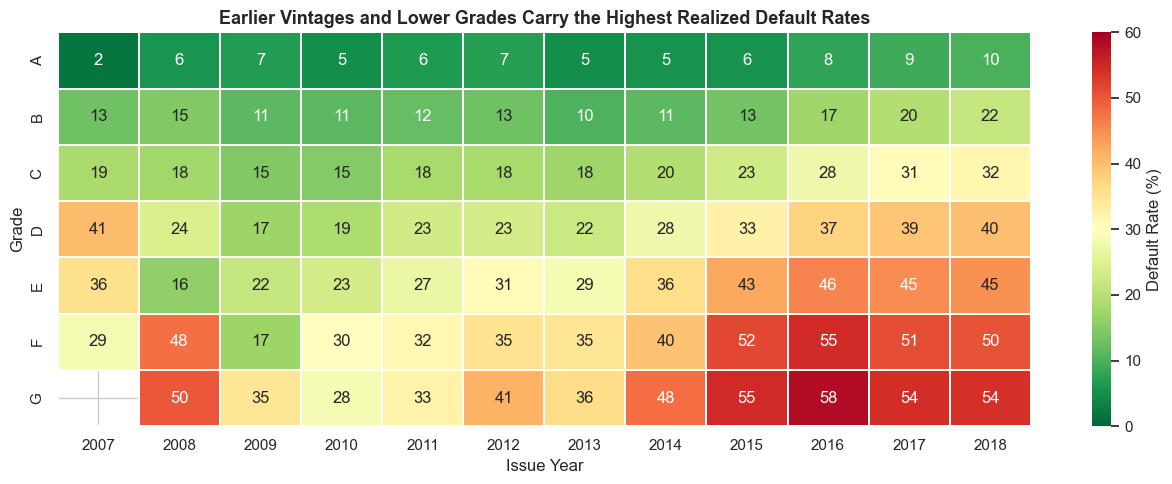

In [36]:
grade_default = (
    df.groupby(["issue_year", "grade"])["default"]
    .mean()
    .mul(100)
    .unstack("grade")
)

plt.figure(figsize=(13, 5))
sns.heatmap(
    grade_default.T,
    cmap="RdYlGn_r",
    annot=True, fmt=".0f",
    linewidths=0.3,
    vmin=0, vmax=60,
    cbar_kws={"label": "Default Rate (%)"},
)
plt.title(
    "Earlier Vintages and Lower Grades Carry the Highest Realized Default Rates",
    fontsize=13, fontweight="bold",
)
plt.xlabel("Issue Year")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()

### Section 5 takeaways

| Metric | Key observation | Business implication |
|---|---|---|
| Loan volume | Peaked in 2015–2016, then contracted | Platform hit a risk-limit or demand inflection; any trend post-2015 must be read in the context of this contraction |
| Vintage default rate | Highest for 2007–2010 cohorts; declines for 2015+ | Maturity bias — 2017–2018 rates will rise as loans complete their term; do not interpret recent vintages as improvement without adjusting for loan age |
| Grade mix evolution | Composition shifted toward D–G grades during the volume scale-up | The increase in portfolio default rates reflects a deliberate (or unchecked) move down the credit spectrum, not just market conditions |
| Default rate by grade × vintage | Grade-level rates should be stable if underwriting quality held | Deteriorating within-grade rates across years would signal loosening standards — this warrants direct validation against the heatmap output |

---

## 6. Key Findings

This section synthesizes the most important insights from the full project — cleaning (Notebook 1), SQL analysis (Notebook 2), and exploratory analysis (Sections 2–5 of this notebook). Every finding is anchored to a specific number from the data.

### Executive Summary

Lending Club originated 1.37 million loans between 2007 and 2018 at a portfolio-wide default rate of **21.47%** — approximately 1 in 5 loans charged off or went delinquent. Credit grade is the dominant risk predictor, with defaults ranging from **6.7% (Grade A) to 51.4% (Grade G)**, a 44.7 percentage-point spread that no other single variable approaches. The dataset reveals that no individual variable cleanly separates defaulters from payers: FICO score is the strongest numeric signal, but the decisive factor is the *combination* of grade, FICO, and DTI — not any one of them alone. Structurally, 60-month loans default at exactly twice the rate of 36-month loans (34.6% vs. 17.2%), and the portfolio's risk profile worsened as volume scaled between 2010 and 2015 through a mix shift toward lower-grade origination, not a deterioration in underwriting quality within each grade.

The profitability picture — quantified in `02_sql_analysis.ipynb` — tells the same story through the income statement: average profit per loan peaked at **$1,926 in 2013**, fell 74% to $505 by 2015 as origination volume peaked at 377K loans, and turned negative by 2016. By 2018, the average loan generated a **−$3,283 loss**. The $257M headline net profit across the full portfolio masks a structural deterioration that was already irreversible by 2015.

---

### Finding 1 — Portfolio Composition Creates Concentrated, Predictable Risk

| Dimension | Key metric |
|---|---|
| Total loans analyzed | **1,371,165** across 2007–2018 |
| Portfolio default rate | **21.47%** |
| Largest purpose segment | Debt consolidation — **~50% of volume at ~21.4% default** |
| Dominant grades by volume | B + C — **~57% of all loans** |
| Class split | 78.5% non-default / 21.5% default |

Debt consolidation alone shapes the headline default rate: it holds ~50% of all volume at a rate essentially equal to the portfolio average, meaning the overall 21.47% figure is, to a significant degree, the debt consolidation segment's default rate. Any material change in origination quality or pricing within this one segment directly moves the portfolio metric. Business loans, by contrast, carry the highest default rate (**31.2%**) and are the only large purpose segment confirmed as loss-making (**–$11.5M**), yet they represent a small share of volume — a rounding error on total losses but a clear pricing failure.

---

### Finding 2 — Credit Grade Is the Strongest Single Risk Differentiator

| Grade | Default rate | Volume share |
|---|---|---|
| A | **6.7%** | ~20% |
| B | **14.6%** | ~29% |
| C | **24.2%** | ~28% |
| D | **33.7%** | ~15% |
| E | **41.9%** | ~6% |
| F | **48.0%** | ~2% |
| G | **51.4%** | ~1% |

Grade delivers a **44.7pp spread** — the widest range of any variable in the dataset. The relationship is monotonic, meaning every step down the risk ladder carries incrementally more default risk with no reversals. Grades B and C, which together hold ~57% of portfolio volume, sit at 14.6% and 24.2% respectively — B is below average, C is above. This means the portfolio is deliberately concentrated at the risk inflection point. Grades D–G represent only ~23% of loans but contribute disproportionate absolute defaults due to their elevated rates.

FICO score reinforces grade from the numeric side: the Fair band (600–699) carries a **25.1% default rate** and accounts for **61% of all volume (~837K loans)**. The Excellent band (750+) drops to 10.1%, a 15pp gap — but the Fair band is where intervention has the highest absolute leverage. Below 600 FICO borrowers are absent from the dataset entirely (rejected at origination), which means the realized default rate of 21.47% likely understates what would occur with a broader credit envelope.

---

### Finding 3 — Loan Term Doubles Default Risk Independently of Grade

| Term | Default rate | Volume |
|---|---|---|
| 36-month | **17.2%** | ~897K loans (66%) |
| 60-month | **34.6%** | ~474K loans (34%) |

60-month loans default at exactly **2× the rate** of 36-month loans. This multiplier operates independently of grade — a Grade C borrower on a 60-month term carries structurally higher risk than a Grade C borrower on a 36-month term, because the longer window exposes them to income shocks, job loss, and financial distress events that may not yet exist at origination. The 34% share of 60-month volume is not a rounding error: it represents nearly half a million loans defaulting at more than one-in-three rate. Term selection likely reflects adverse self-selection — borrowers who choose 60-month are signaling constrained monthly cash flow, which is itself a credit signal not fully captured by the grade assignment.

---

### Finding 4 — No Single Variable Cleanly Separates Defaults; Multi-Variable Scoring Is Required

The correlation analysis reveals a critical modeling constraint: **grade and interest rate are near-perfectly correlated (r ≈ 0.95)** and carry redundant information — using both in any model or scoring framework introduces multicollinearity without adding predictive power. Of the remaining numeric variables, FICO score has the strongest negative correlation with default but still leaves heavy overlap: defaults cluster in the low-FICO / high-DTI quadrant, but the boundary at **FICO 650–700 / DTI 15–30** contains both defaulted and non-defaulted loans at high density. No single threshold cleanly separates the two classes.

---

### Finding 5 — Portfolio Risk Rose as Volume Scaled Through a Mix Shift, Not Underwriting Deterioration

Loan volume peaked in 2015–2016 and then contracted. During the scale-up phase (approximately 2010–2015), the portfolio's grade composition shifted toward D–G origination — the increase in headline default rates reflects this mix shift toward lower-grade lending, not a degradation in the quality of borrowers within each grade. Early vintages (2007–2010) show the highest realized default rates in the heatmap, a consequence of full loan maturity: these cohorts have completed their full 36- or 60-month terms, so their defaults are fully counted. The 2017–2018 vintages show lower rates precisely because many of these loans are still active — their final default rates will be higher once the loans season. **2017–2018 rates are a lower-bound estimate, not a signal of improvement.**

---

### Top 3 Actionable Implications

**1. Tighten 60-month underwriting criteria — this is the highest-leverage structural lever.**
60-month loans at 34.6% default represent the clearest structural inefficiency in the book. The 2× multiplier vs. 36-month at the same grade level means the platform is charging a grade-based rate but not fully pricing the term risk. Separate underwriting thresholds by term — minimum FICO band, maximum DTI, and grade ceiling — would reduce loss exposure without reducing 36-month origination volume.

**2. Build a composite risk score combining grade, FICO, DTI, and term.**
No single variable is sufficient. The combination of grade (strongest categorical predictor), FICO score (strongest numeric predictor), and DTI (compounds with both) outperforms any individual variable across the full FICO 650–700 / DTI 15–30 overlap zone where defaults and non-defaults are currently indistinguishable. A simple scoring matrix combining these three, stratified by term, would meaningfully improve the quality of approval decisions in that gray zone.

**3. Re-price or exit Business loans; protect Debt consolidation pricing.**
Business loans carry the highest default rate (31.2%) and are the only confirmed loss-making purpose segment (–$11.5M). The volume is small enough that exiting the segment or substantially repricing it would have a negligible impact on origination but a disproportionate improvement in portfolio profitability. Debt consolidation, at ~50% of volume and essentially break-even on default rate vs. the portfolio average, is the engine of the book — any pricing or underwriting pressure on this segment should be approached with extreme caution given its outsized influence on the headline default rate.

---

**What comes next — `04_powerbi_report.pbix`**

The three notebooks built the analytical foundation. The Power BI dashboard operationalizes these findings for ongoing portfolio monitoring — with interactive filters that let risk managers explore segment intersections (Grade G + Very High DTI + Fair FICO ≈ 75% default rate) and track the return-rate collapse from +13.09% (2014) to −21.53% (2018) in real time.

---

## Stage 4 — Power BI Dashboard

`04_powerbi_report.pbix` is the final layer of this project. Where the SQL notebook computed exact numbers and the EDA notebook visualized patterns, the dashboard makes the findings **interactive and decision-ready**.

Three capabilities the dashboard adds that static notebooks cannot:

1. **Filter by grade to expose segment-specific profiles** — Grade G + Very High DTI + Fair FICO yields a ~75% default rate (3.5× portfolio average). A risk manager can reach that insight in seconds by adjusting slicers, without running a query.

2. **Cross-filter across dimensions simultaneously** — The purpose × grade interaction matrix (Health/Education + Grade G = 52.67%) is only discoverable interactively. Static charts show one dimension at a time; the dashboard shows them in combination.

3. **Track the return-rate collapse as a time series** — Returns peaked at +13.09% (2014), turned negative by 2016 (−2.15%), and collapsed to −21.53% by 2018. The dashboard annotates this arc with year-by-year labels that make the inflection point unmistakable.

> **Project summary:** `01_data_cleaning.ipynb` built the foundation. `02_sql_analysis.ipynb` discovered where risk concentrates. `03_eda.ipynb` revealed how risk factors interact. `04_powerbi_report.pbix` turns those findings into a monitoring tool. Together, they answer the central question: *1 in 5 Lending Club loans never came back — and the data shows exactly why.*